単純遺伝的アルゴリズム(SGA)で，ナップサック問題を解きます．

ナップサック問題を知らない，という人はとりあえず，Wikipediaの記事に目を通してみましょう．

- ナップサック問題 https://ja.wikipedia.org/wiki/%E3%83%8A%E3%83%83%E3%83%97%E3%82%B5%E3%83%83%E3%82%AF%E5%95%8F%E9%A1%8C
- Knapsack problem https://en.wikipedia.org/wiki/Knapsack_problem

今回の課題では，以下のような設定とします．

- 荷物は20個あり，それぞれ，重さと価値が決まっている
- 1つの荷物の重さの上限は20，価値の上限は20である
- ナップサックに入れる荷物の重さの上限は150である
- ナップサックに入れる荷物は1種類につき1つである
    - つまり，1個体の遺伝子の長さを20とし，荷物を入れるなら1，入れないなら0で表わす

これに従って，**ナップサックの重さ上限に収まり，かつ，価値の合計が最大になるような荷物の組み合わせをSGAで求めます**

ファジィ制御，ニューラルネットワークの課題と同じく，みなさんに書いてほしいところには`"ここを自分で書く"`としてあります．

こちらで用意しているプログラムはPythonっぽくない書き方がたくさんありますが，わかりやすさ優先で書いているためです．

腕に自信のある人は，Pythonのよさを生かしたプログラムに書き換えてもよいです．

## 初期設定

各荷物の重さと価値を決めておきます．重さ，価値ともにランダムに設定します．

In [1]:
import random

N = 20 # 荷物の数
ITEM_W_MAX = 20 # 荷物の重さの最大値
ITEM_P_MAX = 20 # 荷物の価値の最大値

# 各荷物の重さをランダムに設定する
item_w = [random.randint(1, ITEM_W_MAX) for i in range(N)]

# 各荷物の価値をランダムに設定する．価値は1から20の範囲の整数とする．
item_p = [random.randint(1, ITEM_P_MAX) for i in range(N)]

# 各荷物の重さ，価値を表示して確認する
print("各荷物の重さ：", item_w)
print("各荷物の価値：", item_p)

各荷物の重さ： [2, 11, 16, 19, 7, 19, 14, 9, 6, 7, 4, 1, 2, 12, 6, 18, 6, 3, 11, 7]
各荷物の価値： [10, 2, 9, 12, 16, 13, 14, 4, 14, 3, 17, 19, 18, 9, 16, 5, 10, 15, 19, 5]


## 初期個体群（第1世代）の生成

第1世代となる，初期個体群を生成します．初期個体群の遺伝子は，ランダムに決めます．

ここでは，個体群のサイズ（1世代あたりの個体数）は100とします．

個体群は2次元配列で表現します．2次元配列の生成には，便利なNumPyモジュールを使います．

In [2]:
import numpy as np

POPSIZE = 100 # 個体群のサイズ

# 初期個体群を生成する
g = np.random.randint(0, 2, (POPSIZE, N)) # 0以上2未満（1以下）の乱数を，POPSIZE * N の配列の要素とする

# 初期個体群の遺伝子を表示して確認する
# print(g)だと省略表示されてしまうので，個体0番目から9番目のみ表示する
print("初期個体群の遺伝子．g[0]からg[9]まで表示")
print(g[0:10])

初期個体群の遺伝子．g[0]からg[9]まで表示
[[0 0 1 1 0 0 1 0 1 0 0 0 1 1 1 1 1 1 0 1]
 [1 0 1 1 0 0 0 1 1 1 0 0 0 0 1 0 1 0 1 0]
 [0 0 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1]
 [1 0 0 1 1 0 0 0 1 1 1 0 0 1 1 1 1 0 1 1]
 [1 0 1 0 0 1 1 1 1 1 1 0 1 1 0 0 1 0 0 0]
 [0 0 1 0 1 0 1 0 1 0 0 0 1 1 1 1 0 0 0 0]
 [1 1 1 1 0 0 1 0 1 1 1 0 0 0 1 1 1 0 1 1]
 [1 0 1 1 0 0 0 0 1 1 1 1 0 1 0 0 0 0 1 0]
 [0 1 1 1 0 0 0 1 0 0 1 1 0 0 1 1 0 1 1 1]
 [0 1 1 0 0 1 1 0 1 1 0 1 0 1 0 1 0 1 1 1]]


## 課題(1) 現在の世代の個体群について適応度を計算する

初期個体群について，適応度を計算してみましょう．今後のために関数にしておきます．

遺伝子はナップサックに入れる荷物の組み合わせを表しているので，遺伝子が1のときに，荷物の重さと価値をそれぞれ足していけばよいことになります．

ナップサックに入れる荷物の重さは上限が150となっているので，重さが150を超えた場合は価値を0にします．

In [3]:
WEIGHT_MAX = 150 # ナップサックに入れる荷物の重さ上限

def calc_fit():
    """個体群の適応度を計算して，numpy配列で返す"""
    
    # 計算した適応度を格納するための二次元配列を用意する．0で初期化．
    f = np.zeros((POPSIZE, 2))

    # f[i, 0] に重さの合計を入れる．f[i, 0]は，C言語風に表わすとf[i][0]ということ．
    # f[i, 1] に価値の合計を入れる．
    for i in range(POPSIZE):
        for j in range(N):
            # 遺伝子g[i, j]が1なら，対応する荷物の重さと価値を加算する
            if g[i, j] == 1:
                f[i, 0] = f[i, 0] + item_w[j]
                f[i, 1] = f[i, 1] + item_p[j]
        # ただし，重さの合計がWEIGHT_MAXを超えた場合は価値はゼロになる
        if f[i, 0] > WEIGHT_MAX:
            f[i, 1] = 0
    
    return f 

fitness = calc_fit()    
            
print("個体群の適応度（重さと価値）．g[0]からg[9]に対応する適応度を表示")
print(fitness[0:10])

個体群の適応度（重さと価値）．g[0]からg[9]に対応する適応度を表示
[[109. 127.]
 [ 82.  97.]
 [ 82. 118.]
 [105. 136.]
 [ 97. 121.]
 [ 81. 101.]
 [127. 136.]
 [ 78. 112.]
 [105. 123.]
 [125. 127.]]


### いまの世代で最も良い個体を確認する

SGAの実装には直接関係しませんが，最適解に収束しているかどうかを見るために，今の世代で最も良い個体を確認しておくのは重要です．

In [4]:
best_id = 0
for i in range(POPSIZE):
    if fitness[i, 1] > fitness[best_id, 1]:
        best_id = i

print("いまの最も良い個体")
print("個体番号：", best_id, " 遺伝子：", g[best_id], " 重さ：", fitness[best_id, 0], " 価値：", fitness[best_id, 1])

いまの最も良い個体
個体番号： 76  遺伝子： [1 0 1 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 0]  重さ： 150.0  価値： 174.0


## 課題(2) 選択

個体群の適応度が計算できたので，選択の操作を行います．選択の操作も関数にしておきます．

単純遺伝的アルゴリズムでは，ルーレット選択のみを使います．

ルーレット選択を実装する際の考え方については，`moodleトピック13 【課題】単純遺伝的アルゴリズムの実装`に説明を載せていますので参考にしてください．

In [5]:
def selection():
    """ルーレット選択を行い，選択された個体をnumpy配列で返す"""
    # 選択された個体を保持するための配列を用意しておく
    t = np.zeros((POPSIZE, N))

    # ルーレット選択で親となる個体を選ぶ
    # 1. 個体群の適応度（価値）の総和を計算して，roulette_totalに代入する
    roulette_total = 0
    for i in range(POPSIZE):
        roulette_total = roulette_total + fitness[i, 1]

    for i in range(POPSIZE):
        # 2. 0〜個体群の価値の総和-1 の範囲で整数乱数をひとつ生成する
        roulette_arrow = random.randrange(0, roulette_total)
    
        # 3-1. 各個体の適応度（価値）をひとつずつ足していき，
        # 3-2. 価値の総和がroulette_arrowを超えた時，その個体を親とする
        # 4. これを親個体の数がPOPSIZEになるまで繰り返す
        roulette_sum = 0
        for k in range(POPSIZE):
            roulette_sum = roulette_sum + fitness[k, 1]
            # ルーレットに当たったら，選択された個体用の配列tに遺伝子をコピーする
            if roulette_sum > roulette_arrow:
                for j in range(N):
                    t[i, j] = g[k, j]
                break

    return t

g_temp = selection()
                
# 選択された個体の確認
print("選択された個体0番目から9番目までを表示")
print(g_temp[0:9])

選択された個体0番目から9番目までを表示
[[1. 0. 1. 1. 1. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1.]
 [0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1.]
 [1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0.]
 [1. 1. 1. 1. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 1. 1. 1. 0. 1. 1.]
 [0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0.]
 [0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 1. 1.]
 [1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0.]]


## 課題(3) 交叉

親となる個体を選び終わったら，交叉確率にもとづいて，1点交叉で子個体を生成します．

In [6]:
PC = 0.9 # 交叉確率

def cross():
    """1点交叉を行う"""
    for i in range(0, POPSIZE, 2):
        # 0.0〜1.0の乱数を生成する
        cross_rand = random.random()
    
        # 交叉確率にもとづいて，交叉を行う
        # cross_randが交叉確率PC未満のとき
        if cross_rand < PC:
            # 交叉点を決める
            cross_pos = random.randrange(0, N)
        
            # 交叉点より後ろの遺伝子を入れ替える
            for j in range(cross_pos, N):
                cross_temp = g_temp[i, j]
                g_temp[i, j] = g_temp[i+1, j]
                g_temp[i+1, j] = cross_temp
            
# 交叉後の個体の確認
print("交叉後の個体0番目から9番目までを表示")
print(g_temp[0:9])

交叉後の個体0番目から9番目までを表示
[[1. 0. 1. 1. 1. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1.]
 [0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1.]
 [1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0.]
 [1. 1. 1. 1. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 1. 1. 1. 0. 1. 1.]
 [0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0.]
 [0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 1. 1.]
 [1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0.]]


## 課題(4) 突然変異

子個体に対して，突然変異確率にもとづいて，遺伝子の書き換えを行います．

In [7]:
PM = 0.05 # 突然変異確率

def mutation():
    """突然変異を行う"""
    for i in range(POPSIZE):
        for j in range(N):
        
            # 個体の遺伝子座ごとに，0.0〜1.0の乱数を生成する
            mut_rand = random.random()
        
            # mut_randが突然変異確率以下なら遺伝子を書き換える（反転させる）
            # mut_randが突然変異確率より大きいなら，遺伝子はそのまま
            if mut_rand < PM:
                if g_temp[i, j] == 0:
                    g_temp[i, j] = 1
                else:
                    g_temp[i, j] = 0

                
# 突然変異後の個体の確認
print("突然変異後の個体0番目から9番目までを表示")
print(g_temp[0:9])

突然変異後の個体0番目から9番目までを表示
[[1. 0. 1. 1. 1. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1.]
 [0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1.]
 [1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0.]
 [1. 1. 1. 1. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 1. 1. 1. 0. 1. 1.]
 [0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0.]
 [0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 1. 1.]
 [1. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0.]]


## 選択・交叉・突然変異後の子個体を新しい世代の個体とする

選択・交叉・突然変異が終わったら，子個体を新しい世代の個体とします．

In [8]:
for i in range(POPSIZE):
    for j in range(N):
        g[i, j] = g_temp[i, j]
        
# 新しい世代の個体を確認する．↑の突然変異後の個体と同じになっているはず
print("新しい世代の個体0番目から9番目までを表示")
print(g[0:9])

新しい世代の個体0番目から9番目までを表示
[[1 0 1 1 1 0 1 0 0 0 0 1 1 1 1 1 0 0 1 1]
 [0 1 0 0 1 0 0 0 1 0 1 0 1 0 1 1 1 0 1 1]
 [1 1 0 1 0 1 0 0 0 1 1 1 0 0 1 1 1 1 1 1]
 [1 0 1 1 0 1 0 0 0 0 1 0 1 1 1 1 1 1 1 0]
 [1 1 1 1 0 0 1 0 1 1 1 0 0 0 1 1 1 0 1 1]
 [0 0 1 1 1 0 0 0 1 0 0 1 1 0 0 1 0 1 1 0]
 [0 0 0 0 1 1 1 1 1 0 0 1 1 1 0 0 1 0 1 1]
 [1 0 1 1 0 1 0 0 0 0 1 0 1 1 1 1 1 1 1 0]
 [0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 1 0]]


## 選択・交叉・突然変異を繰り返す

ここまでは1世代分の処理となります．

この処理を終了条件が満たされるまで行うことで，最適解を求めることができます．

では，単純遺伝的アルゴリズムのプログラムをまとめましょう．

ここでは，最適解に向かって収束する様子がわかるように，初期個体群をわざと適応度が低くなるようにしてあります．

また，収束する様子をわかりやすくするために，グラフ描画のためのプログラムを追加しています．

各荷物の重さ： [5, 4, 1, 17, 5, 16, 4, 11, 14, 6, 2, 18, 18, 7, 2, 20, 10, 11, 18, 5]
各荷物の価値： [6, 18, 14, 7, 1, 18, 14, 18, 18, 9, 2, 18, 16, 15, 3, 19, 19, 13, 10, 17]
ベスト個体 番号： 34  遺伝子： [0 1 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0 0 0]  重さ： 85.0  価値： 103.0
ベスト個体 番号： 53  遺伝子： [1 1 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0 0 1]  重さ： 95.0  価値： 126.0
ベスト個体 番号： 8  遺伝子： [0 1 0 0 0 1 1 0 1 0 0 1 1 0 0 1 1 0 0 0]  重さ： 104.0  価値： 140.0
ベスト個体 番号： 40  遺伝子： [1 1 1 0 0 0 1 0 1 0 0 1 1 0 0 1 1 0 1 1]  重さ： 117.0  価値： 169.0
ベスト個体 番号： 68  遺伝子： [1 1 0 0 0 0 1 1 1 0 0 1 1 0 0 0 1 0 1 1]  重さ： 107.0  価値： 154.0
ベスト個体 番号： 42  遺伝子： [1 1 1 0 0 1 0 1 0 1 0 1 1 0 1 1 0 1 1 1]  重さ： 135.0  価値： 179.0
ベスト個体 番号： 34  遺伝子： [0 1 1 0 1 0 1 1 1 1 0 1 1 1 0 0 1 1 0 1]  重さ： 114.0  価値： 190.0
ベスト個体 番号： 55  遺伝子： [1 1 1 0 1 1 1 1 1 0 0 1 0 0 0 1 1 1 1 1]  重さ： 142.0  価値： 203.0
ベスト個体 番号： 8  遺伝子： [1 1 1 1 0 1 1 1 1 1 0 0 0 1 0 0 1 1 1 1]  重さ： 129.0  価値： 196.0
ベスト個体 番号： 53  遺伝子： [1 1 1 0 1 1 1 1 1 1 0 1 1 0 0 1 1 0 0 1]  重さ： 137.0  価値： 205.0
ベスト個体 番号： 75

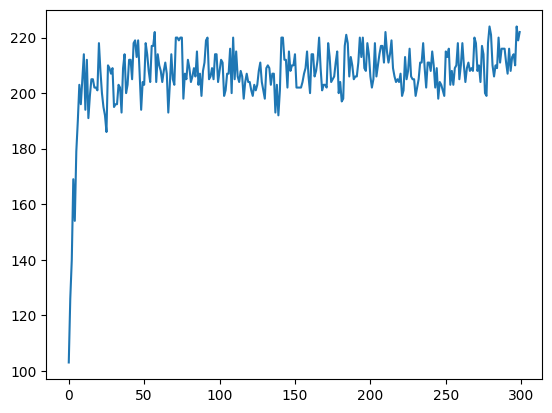

In [9]:
%matplotlib inline

import random
import numpy as np
import matplotlib.pyplot as plt

N = 20 # 荷物の数
ITEM_W_MAX = 20 # 荷物の重さの最大値
ITEM_P_MAX = 20 # 荷物の価値の最大値
POPSIZE = 100 # 個体群のサイズ
WEIGHT_MAX = 150 # ナップサックに入れる荷物の重さ上限
PC = 0.9 # 交叉確率
PM = 0.05 # 突然変異確率
GENE_MAX = 300 # 世代の上限数


# 各荷物の重さをランダムに設定する
item_w = [random.randint(1, ITEM_W_MAX) for i in range(N)]

# 各荷物の価値をランダムに設定する．価値は1から20の範囲の整数とする．
item_p = [random.randint(1, ITEM_P_MAX) for i in range(N)]

# 各荷物の重さ，価値を表示して確認する
print("各荷物の重さ：", item_w)
print("各荷物の価値：", item_p)

# 初期個体群を生成する
# 収束しているかどうかわかりやすくするために，わざと適応度が低い個体群を生成する
g = ((np.random.rand(POPSIZE*N) * np.random.rand(POPSIZE*N)).reshape(POPSIZE, N) > 0.5).astype(int)

# その世代で最も良い適応度を記録するための配列を用意する
best = np.zeros(GENE_MAX)

# ここから，世代の上限数まで繰り返す
for t in range(GENE_MAX):
    
    # いまの世代の個体群について適応度を計算する
    fitness = calc_fit()

    # いまの世代で最も良い個体を確認する
    best_id = 0
    for i in range(POPSIZE):
        if fitness[i, 1] > fitness[best_id, 1]:
            best_id = i
    # 最も良い個体の適応度（価値）を記録する
    best[t] = fitness[best_id, 1]

    print("ベスト個体 番号：", best_id, " 遺伝子：", g[best_id], " 重さ：", fitness[best_id, 0], " 価値：", fitness[best_id, 1])

    # ルーレット選択を行う
    g_temp = selection()
    
    # 1点交叉を行う            
    cross()
    
    # 突然変異を行う
    mutation()
                
    # 子個体を新しい個体とする
    for i in range(POPSIZE):
        for j in range(N):
            g[i, j] = g_temp[i, j]
            
            
# 適応度（価値）のグラフ描画
plt.plot(best)
# plt.savefig('simpleGA.png')